# 1 Introduction

Phishing websites are malicious sites designed to imitate legitimate services and trick users into revealing credentials, payment details, or other sensitive information. Detecting phishing websites is a common cybersecurity data science task because many suspicious properties can be represented as structured features, such as URL patterns, domain behavior, and webpage interaction signals.

This notebook reproduces and critically evaluates the original `Phishing-Website-Detection` project using its provided training dataset. At this stage, the focus is only on loading and inspecting the data so that later modelling decisions can be based on a clear understanding of the dataset.

# 2 Load Dataset

The dataset is loaded from the local reproducibility path `data/5.urldata.csv`. The file should be copied from the original repository without modification. The following checks display the dataset shape, the first rows, structural information, and descriptive statistics.


In [1]:
from pathlib import Path

from IPython.display import Markdown, display
import os
import pandas as pd

os.environ.setdefault("MPLCONFIGDIR", str(Path("figures") / ".matplotlib"))

DATA_PATH = Path("data/5.urldata.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Dataset not found at data/5.urldata.csv. "
        "Create the local data/ folder if needed and copy 5.urldata.csv "
        "from the original repository's DataFiles/ directory into data/. "
        "Original repository: https://github.com/gangeshbaskerr/Phishing-Website-Detection"
    )

df = pd.read_csv(DATA_PATH)

print(f"Dataset path: {DATA_PATH}")
print(f"Shape: {df.shape}")


Dataset path: data/5.urldata.csv
Shape: (10000, 18)


In [2]:
df.head()

,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
0,graphicriver.net,0,0,1,1,0,0,0,0,0,1,1,1,0,0,1,0,0
1,ecnavi.jp,0,0,1,1,1,0,0,0,0,1,1,1,0,0,1,0,0
2,hubpages.com,0,0,1,1,0,0,0,0,0,1,0,1,0,0,1,0,0
3,extratorrent.cc,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0
4,icicibank.com,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Domain         10000 non-null  object
 1   Have_IP        10000 non-null  int64 
 2   Have_At        10000 non-null  int64 
 3   URL_Length     10000 non-null  int64 
 4   URL_Depth      10000 non-null  int64 
 5   Redirection    10000 non-null  int64 
 6   https_Domain   10000 non-null  int64 
 7   TinyURL        10000 non-null  int64 
 8   Prefix/Suffix  10000 non-null  int64 
 9   DNS_Record     10000 non-null  int64 
 10  Web_Traffic    10000 non-null  int64 
 11  Domain_Age     10000 non-null  int64 
 12  Domain_End     10000 non-null  int64 
 13  iFrame         10000 non-null  int64 
 14  Mouse_Over     10000 non-null  int64 
 15  Right_Click    10000 non-null  int64 
 16  Web_Forwards   10000 non-null  int64 
 17  Label          10000 non-null  int64 
dtypes: int64(17), object(1)
mem

In [4]:
df.describe(include="all")

,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
count,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000,10000.00000,10000.00000,10000.000000,10000.000000
unique,3553,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,torcache.net,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.005500,0.022600,0.773400,3.072000,0.013500,0.000200,0.090300,0.093200,0.100800,0.845700,0.413700,0.8099,0.090900,0.06660,0.99930,0.105300,0.500000
std,NaN,0.073961,0.148632,0.418653,2.128631,0.115408,0.014141,0.286625,0.290727,0.301079,0.361254,0.492521,0.3924,0.287481,0.24934,0.02645,0.306955,0.500025
min,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.00000,0.00000,0.000000,0.000000
25%,NaN,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.0000,0.000000,0.00000,1.00000,0.000000,0.000000
50%,NaN,0.000000,0.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.0000,0.000000,0.00000,1.00000,0.000000,0.500000
75%,NaN,0.000000,0.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.0000,0.000000,0.00000,1.00000,0.000000,1.000000


# 3 Data Inspection

This section inspects the dataset before any modelling work. The goal is to understand the feature names, data types, target variable, duplicated records, and missing values. These checks help identify potential data quality issues and clarify how the dataset should be prepared in later stages.

Column names are inspected to understand what each field represents and to verify that the loaded dataset matches the expected phishing website feature table. Clear column names are important because later feature engineering and evaluation steps depend on referencing the correct variables.

In [5]:
columns = pd.DataFrame({
    "position": range(len(df.columns)),
    "column_name": df.columns,
})

columns

,position,column_name
0,0,Domain
1,1,Have_IP
2,2,Have_At
3,3,URL_Length
4,4,URL_Depth
5,5,Redirection
6,6,https_Domain
7,7,TinyURL
8,8,Prefix/Suffix
9,9,DNS_Record


Data types are reviewed to confirm whether features are numeric, categorical, or text-based. This matters because numeric feature columns can usually be passed directly to many machine learning models, while text or categorical columns may require additional preprocessing.

In [6]:
data_types = df.dtypes.reset_index()
data_types.columns = ["column_name", "data_type"]

data_types

,column_name,data_type
0,Domain,object
1,Have_IP,int64
2,Have_At,int64
3,URL_Length,int64
4,URL_Depth,int64
5,Redirection,int64
6,https_Domain,int64
7,TinyURL,int64
8,Prefix/Suffix,int64
9,DNS_Record,int64


The target column contains the class label that a future model would try to predict. In this dataset, `Label` is treated as the target column. Its distribution is inspected to understand the balance between the classes before any model training is attempted.

In [7]:
target_column = "Label"

if target_column not in df.columns:
    raise ValueError(f"Expected target column '{target_column}' was not found in the dataset.")

target_summary = pd.DataFrame({
    "count": df[target_column].value_counts(dropna=False),
    "proportion": df[target_column].value_counts(normalize=True, dropna=False),
})

target_summary

,count,proportion
Label,,
0,5000,0.5
1,5000,0.5


Duplicated rows are checked because repeated observations can bias evaluation results, especially if duplicates appear in both training and testing splits later. At this stage, duplicates are only reported and not removed, so the original dataset remains unchanged for reproducibility.

In [8]:
duplicate_count = df.duplicated().sum()
duplicate_rate = duplicate_count / len(df)

pd.DataFrame({
    "duplicated_rows": [duplicate_count],
    "duplicate_rate": [duplicate_rate],
})

,duplicated_rows,duplicate_rate
0,5626,0.5626


Missing values are inspected to identify whether any columns require imputation, removal, or special handling in future preprocessing. The count and percentage of missing values are shown for every column so that data quality can be evaluated feature by feature.

In [9]:
missing_values = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_rate": df.isna().mean(),
}).sort_values("missing_count", ascending=False)

missing_values

,missing_count,missing_rate
Domain,0,0.0
Have_IP,0,0.0
Web_Forwards,0,0.0
Right_Click,0,0.0
Mouse_Over,0,0.0
iFrame,0,0.0
Domain_End,0,0.0
Domain_Age,0,0.0
Web_Traffic,0,0.0
DNS_Record,0,0.0


# 4 Exploratory Data Analysis

This section explores the dataset visually before any model training. The goal is to understand class balance, feature distributions, missingness, duplicate rows, and relationships between engineered features. Important figures are saved to the local `figures/` folder when the notebook is executed.

In [10]:
import math

ipython = get_ipython() if "get_ipython" in globals() else None
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

plt.style.use("default")

The class balance plot shows how many examples belong to each target class. This is important because a strongly imbalanced dataset can make accuracy misleading and may require more careful evaluation metrics later.

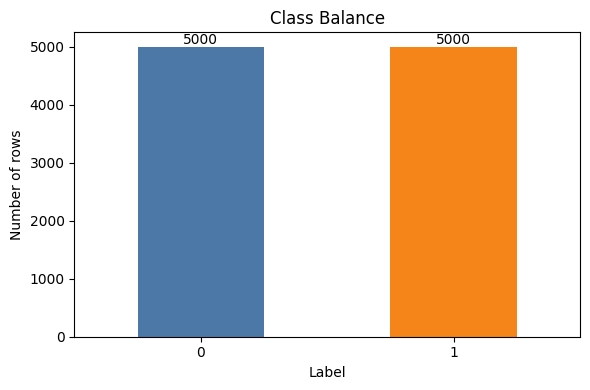

In [11]:
class_counts = df[target_column].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
class_counts.plot(kind="bar", ax=ax, color=["#4C78A8", "#F58518"])
ax.set_title("Class Balance")
ax.set_xlabel(target_column)
ax.set_ylabel("Number of rows")
ax.set_xticklabels(class_counts.index.astype(str), rotation=0)

for position, value in enumerate(class_counts):
    ax.text(position, value, str(value), ha="center", va="bottom")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

The engineered numeric and binary features are plotted to inspect their value distributions. Most columns are encoded as small integer indicators, so bar plots are more readable than continuous histograms for this dataset.

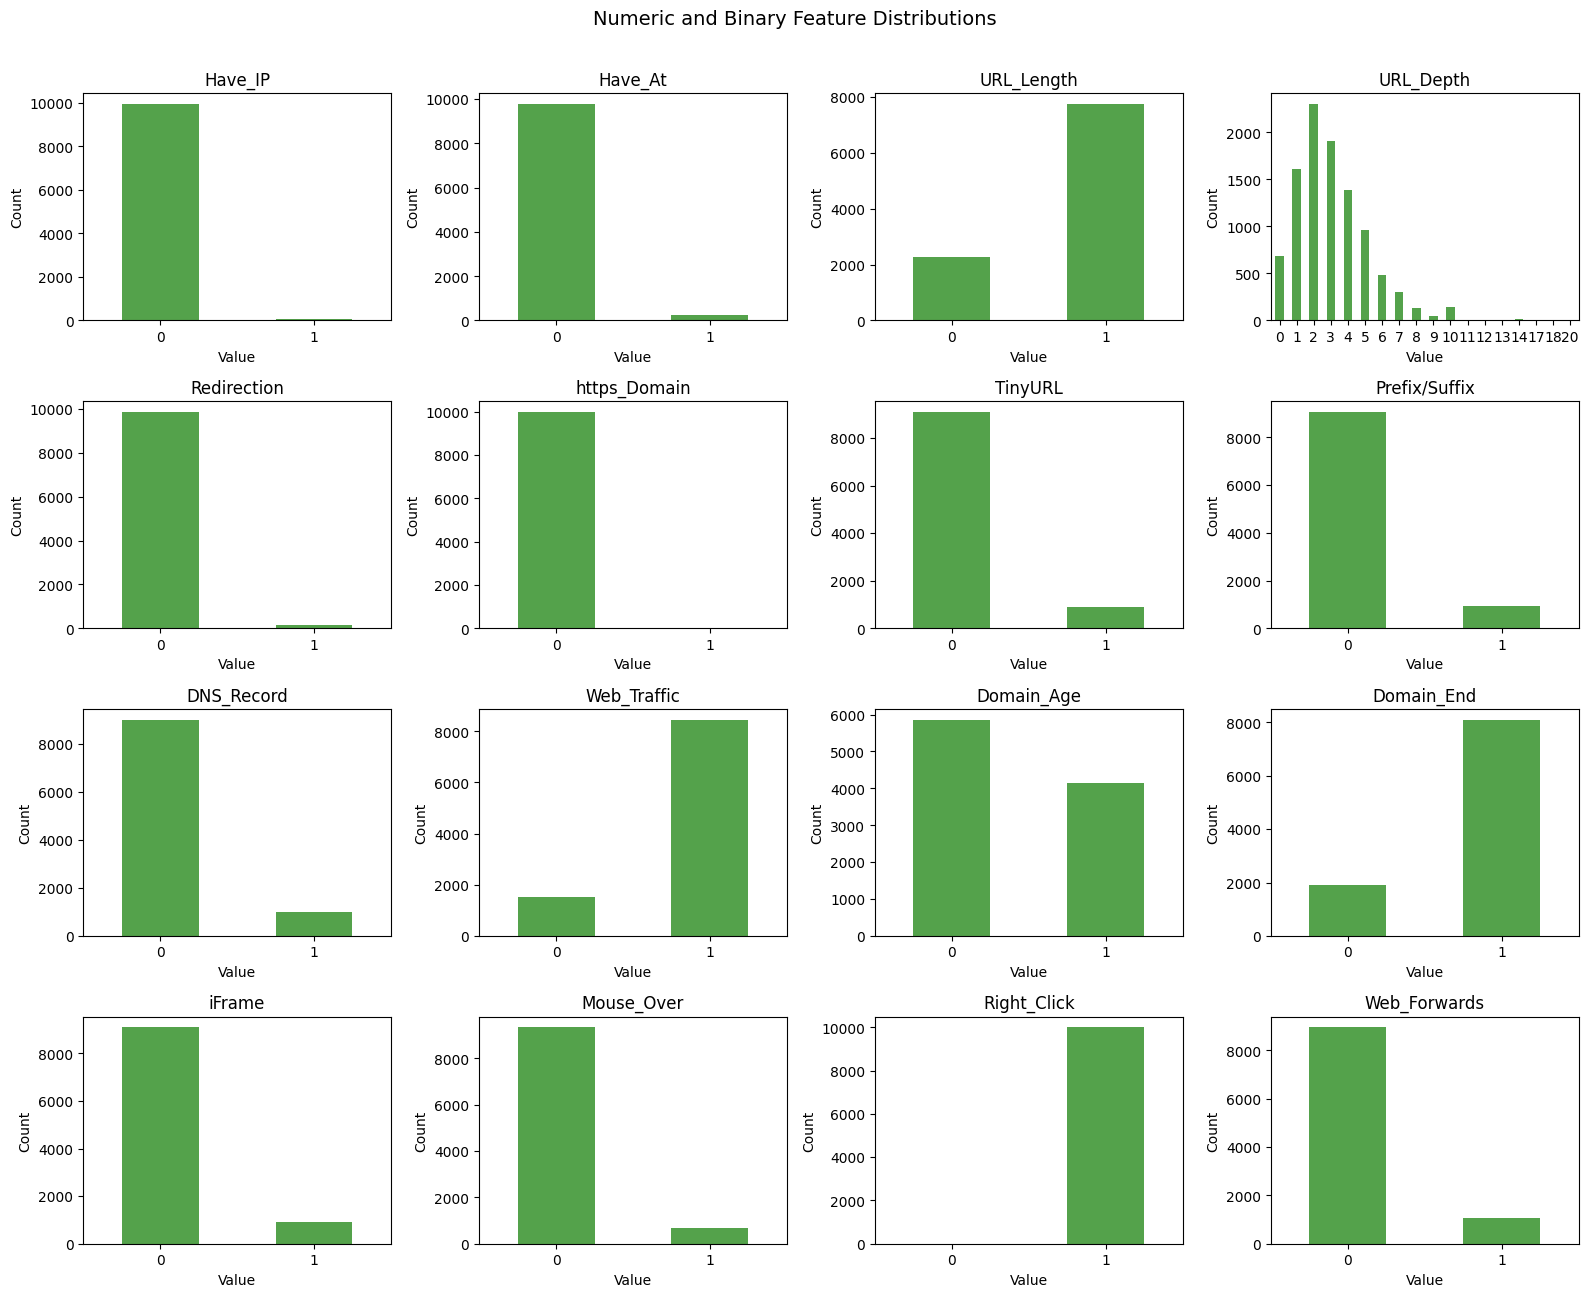

In [12]:
feature_columns = [column for column in df.columns if column not in ["Domain", target_column]]
numeric_feature_columns = df[feature_columns].select_dtypes(include="number").columns.tolist()

n_columns = 4
n_rows = math.ceil(len(numeric_feature_columns) / n_columns)

fig, axes = plt.subplots(n_rows, n_columns, figsize=(16, 3.2 * n_rows))
axes = axes.flatten()

for ax, column in zip(axes, numeric_feature_columns):
    counts = df[column].value_counts(dropna=False).sort_index()
    counts.plot(kind="bar", ax=ax, color="#54A24B")
    ax.set_title(column)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=0)

for ax in axes[len(numeric_feature_columns):]:
    ax.set_visible(False)

fig.suptitle("Numeric and Binary Feature Distributions", y=1.01, fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

Missing value visualization helps confirm whether missingness is concentrated in specific features or absent from the dataset. A visual check is useful even when the tabular missing-value summary already reports the counts.

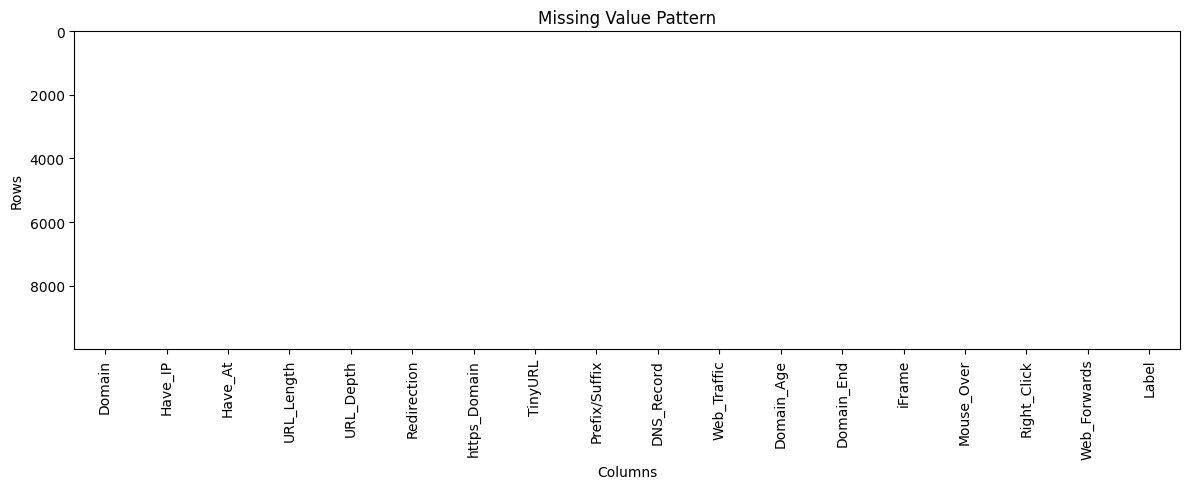

In [13]:
missing_indicator = df.isna()

fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(missing_indicator, aspect="auto", interpolation="nearest", cmap="Greys")
ax.set_title("Missing Value Pattern")
ax.set_xlabel("Columns")
ax.set_ylabel("Rows")
ax.set_xticks(range(len(df.columns)))
ax.set_xticklabels(df.columns, rotation=90)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "missing_values.png", dpi=150, bbox_inches="tight")
plt.show()

Duplicate rows are important to discuss before modelling. If identical rows are present, a later random train-test split could place copies of the same observation in both sets, making performance look better than it really is. For now, duplicates are reported only; no rows are removed in this exploratory notebook.

In [14]:
duplicate_summary = pd.DataFrame({
    "total_rows": [len(df)],
    "duplicated_rows": [df.duplicated().sum()],
    "duplicate_rate": [df.duplicated().mean()],
})

duplicate_summary

,total_rows,duplicated_rows,duplicate_rate
0,10000,5626,0.5626


A Spearman correlation matrix is used because the engineered features are mostly binary or ordinal integer indicators rather than continuous measurements. Spearman correlation is rank-based, so it is better suited for monotonic relationships and encoded ordered values than Pearson correlation, which assumes linear relationships between continuous variables.

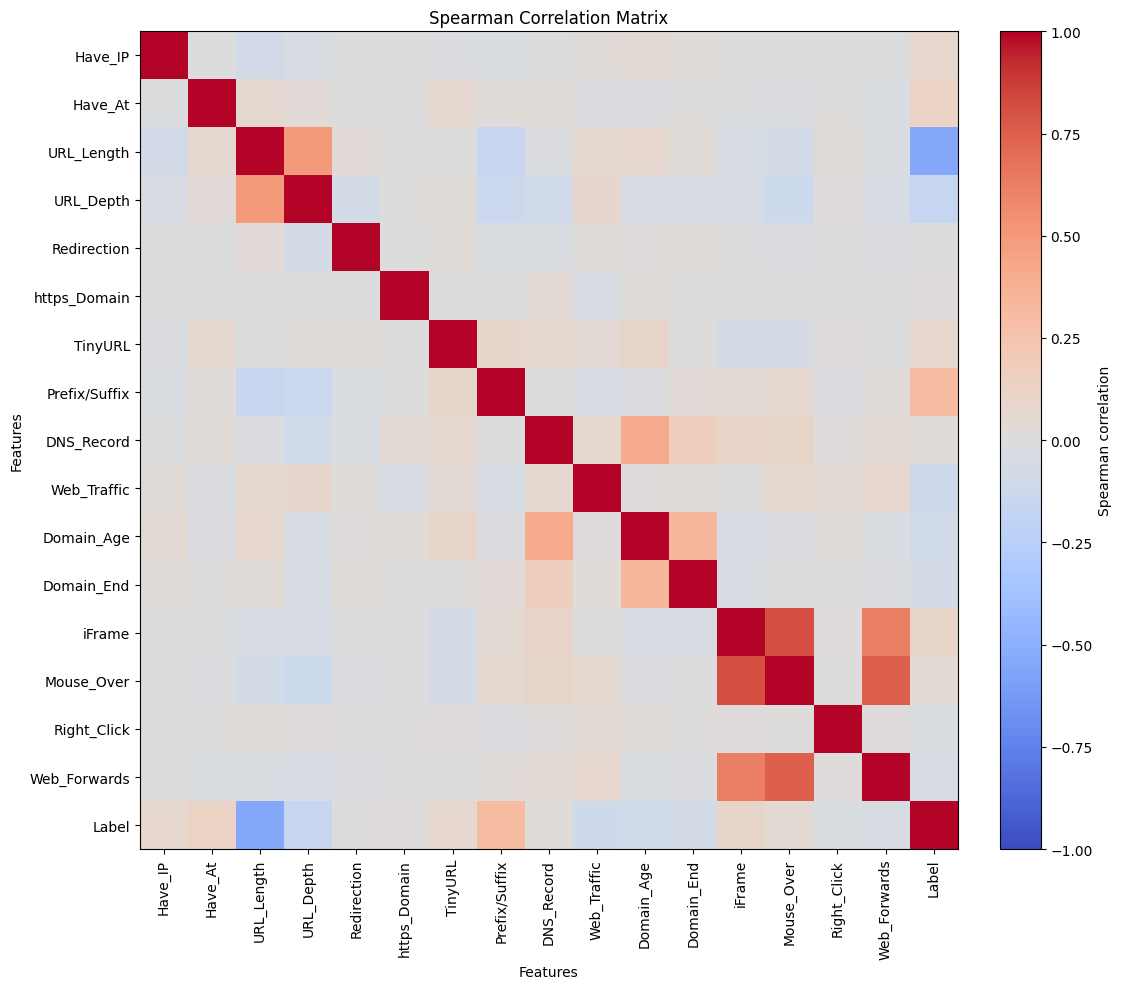

,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
Have_IP,1.000000,-0.011308,-0.076021,-0.031848,-0.008700,-0.001052,-0.023430,-0.023841,-0.011425,0.024279,0.047349,0.018799,-0.004701,0.007251,0.001968,-0.003487,0.074367
Have_At,-0.011308,1.000000,0.067844,0.034450,-0.000297,-0.002151,0.067122,0.018369,0.025073,-0.017002,-0.017072,0.001651,-0.008294,-0.021728,0.004025,-0.030246,0.118419
URL_Length,-0.076021,0.067844,1.000000,0.496164,0.038482,0.007656,-0.005318,-0.146102,-0.019508,0.063717,0.071029,0.028755,-0.039903,-0.068104,0.030833,-0.023651,-0.541287
URL_Depth,-0.031848,0.034450,0.496164,1.000000,-0.062747,0.002730,0.023627,-0.122143,-0.085516,0.083927,-0.046488,-0.044037,-0.047067,-0.115261,0.010550,-0.048351,-0.150088
Redirection,-0.008700,-0.000297,0.038482,-0.062747,1.000000,-0.001655,0.026634,-0.025581,-0.027654,0.018784,0.012581,0.025758,-0.012876,-0.017346,0.003096,-0.023193,0.002600
https_Domain,-0.001052,-0.002151,0.007656,0.002730,-0.001655,1.000000,-0.004456,-0.004534,0.042243,-0.033112,0.016837,0.006852,-0.004472,-0.003778,0.000374,-0.004852,0.014144
TinyURL,-0.023430,0.067122,-0.005318,0.023627,0.026634,-0.004456,1.000000,0.087421,0.059078,0.040888,0.095944,0.006812,-0.062000,-0.054771,0.008339,-0.003508,0.072921
Prefix/Suffix,-0.023841,0.018369,-0.146102,-0.122143,-0.025581,-0.004534,0.087421,1.000000,-0.006793,-0.046843,-0.019954,0.031711,0.050594,0.070263,-0.017527,0.030102,0.302705
DNS_Record,-0.011425,0.025073,-0.019508,-0.085516,-0.027654,0.042243,0.059078,-0.006793,1.000000,0.065776,0.398583,0.162210,0.103266,0.094410,0.008861,0.042050,0.015943
Web_Traffic,0.024279,-0.017002,0.063717,0.083927,0.018784,-0.033112,0.040888,-0.046843,0.065776,1.000000,0.013681,0.015998,0.006990,0.057473,0.051495,0.073485,-0.108793


In [15]:
correlation_columns = numeric_feature_columns + [target_column]
spearman_corr = df[correlation_columns].corr(method="spearman")

fig, ax = plt.subplots(figsize=(12, 10))
image = ax.imshow(spearman_corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_title("Spearman Correlation Matrix")
ax.set_xticks(range(len(spearman_corr.columns)))
ax.set_yticks(range(len(spearman_corr.columns)))
ax.set_xlabel("Features")
ax.set_ylabel("Features")
ax.set_xticklabels(spearman_corr.columns, rotation=90)
ax.set_yticklabels(spearman_corr.columns)
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="Spearman correlation")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "spearman_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

spearman_corr

The `Domain` column contains raw website domain strings. It should not be used directly as a numeric feature because assigning arbitrary numbers to domain names would create meaningless ordering and distance relationships. If domain information is used later, it should be transformed through deliberate feature engineering, such as extracting length, token patterns, suspicious characters, or other interpretable URL/domain attributes.

# 5 Feature Engineering and Preprocessing

This section defines the modelling inputs and prepares preprocessing options for later experiments. No models are trained here. The goal is to create a reproducible train/test split and prepare separate feature representations for model families with different preprocessing needs.

The feature matrix `X` contains the engineered phishing-detection features, and the target vector `y` contains the `Label` column. The raw `Domain` column is excluded from `X` because it is text data and should not be treated as a numeric predictor directly. Turning domain names into arbitrary numeric codes would introduce fake ordering and distances between unrelated websites.

In [16]:
excluded_columns = ["Domain", target_column]

X = df.drop(columns=excluded_columns)
y = df[target_column]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
X.head()

X shape: (10000, 16)
y shape: (10000,)


,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards
0,0,0,1,1,0,0,0,0,0,1,1,1,0,0,1,0
1,0,0,1,1,1,0,0,0,0,1,1,1,0,0,1,0
2,0,0,1,1,0,0,0,0,0,1,0,1,0,0,1,0
3,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0
4,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0


Feature types and unique values are inspected before preprocessing. This verifies that the model input columns are numeric and helps confirm that most features are binary or low-cardinality ordinal indicators.

In [17]:
feature_type_summary = pd.DataFrame({
    "data_type": X.dtypes,
    "unique_values_count": X.nunique(),
    "unique_values": [sorted(X[column].dropna().unique().tolist()) for column in X.columns],
})

feature_type_summary

,data_type,unique_values_count,unique_values
Have_IP,int64,2,"[0, 1]"
Have_At,int64,2,"[0, 1]"
URL_Length,int64,2,"[0, 1]"
URL_Depth,int64,18,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
Redirection,int64,2,"[0, 1]"
https_Domain,int64,2,"[0, 1]"
TinyURL,int64,2,"[0, 1]"
Prefix/Suffix,int64,2,"[0, 1]"
DNS_Record,int64,2,"[0, 1]"
Web_Traffic,int64,2,"[0, 1]"


Scaling is usually not required for tree-based models such as decision trees and random forests because they split features by thresholds and are not sensitive to feature magnitude in the same way as distance-based or gradient-based linear models. Logistic Regression, however, benefits from standardized inputs because scaling puts features on comparable ranges, improves optimization behavior, and makes regularization affect coefficients more evenly.


The data is split into training and testing sets using a fixed random seed for reproducibility. Stratification preserves the class distribution of `Label` in both sets, which is important for fair evaluation when comparing models later.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_test)],
    "label_0_rate": [(y_train == 0).mean(), (y_test == 0).mean()],
    "label_1_rate": [(y_train == 1).mean(), (y_test == 1).mean()],
}, index=["train", "test"])

split_summary

,rows,label_0_rate,label_1_rate
train,8000,0.5,0.5
test,2000,0.5,0.5


Two preprocessing versions are prepared for future modelling. The first version keeps the numeric engineered features unscaled for tree-based models. The second version defines a `StandardScaler` preprocessing pipeline for Logistic Regression. The scaler is not fitted here; fitting should happen only inside later training workflows to avoid data leakage.

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

numeric_columns = X.columns.tolist()

# Version 1: unscaled numeric features for tree-based models.
X_train_tree = X_train.copy()
X_test_tree = X_test.copy()

# Version 2: StandardScaler preprocessing for Logistic Regression.
logistic_preprocessor = Pipeline(steps=[
    ("scaler", StandardScaler()),
])

logistic_preprocessing_pipeline = ColumnTransformer(
    transformers=[
        ("numeric", logistic_preprocessor, numeric_columns),
    ],
    remainder="drop",
)

preprocessing_summary = pd.DataFrame({
    "version": ["tree_based_unscaled", "logistic_regression_scaled"],
    "description": [
        "Uses the engineered numeric features without scaling.",
        "Applies StandardScaler to numeric features before Logistic Regression.",
    ],
})

preprocessing_summary

,version,description
0,tree_based_unscaled,Uses the engineered numeric features without s...
1,logistic_regression_scaled,Applies StandardScaler to numeric features bef...


# 6 Model Training and Evaluation

This section trains and evaluates baseline models using the existing `X_train`, `X_test`, `y_train`, and `y_test` split. The raw `Domain` column remains excluded because the feature matrix was already created without it. The models are compared with several classification metrics so that evaluation is not based on accuracy alone.

In phishing detection, a false positive means a legitimate website is incorrectly flagged as phishing. This can frustrate users, block access to valid services, and create unnecessary investigation work. A false negative means a phishing website is incorrectly classified as legitimate, which is often more dangerous because users may be exposed to credential theft, malware, or financial fraud.

The Logistic Regression model uses the `StandardScaler` preprocessing pipeline defined earlier. The tree-based models use the unscaled numeric features because decision trees and random forests do not require standardized feature scales for their split-based learning process.

In [20]:
import warnings

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier


def make_models():
    return {
        "Logistic Regression": Pipeline(steps=[
            ("preprocessor", logistic_preprocessing_pipeline),
            ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
        ]),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    }


models = make_models()
models


{'Logistic Regression': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('numeric',
                                                   Pipeline(steps=[('scaler',
                                                                    StandardScaler())]),
                                                   ['Have_IP', 'Have_At',
                                                    'URL_Length', 'URL_Depth',
                                                    'Redirection',
                                                    'https_Domain', 'TinyURL',
                                                    'Prefix/Suffix',
                                                    'DNS_Record', 'Web_Traffic',
                                                    'Domain_Age', 'Domain_End',
                                                    'iFrame', 'Mouse_Over',
                                                    'Right_Click',
                                          

Each model is trained on the training set and evaluated on the held-out test set. Accuracy shows the overall share of correct predictions, while precision, recall, F1 score, F2 score, Matthews Correlation Coefficient, ROC-AUC, and PR-AUC provide a more complete view of classification quality. F2 score gives extra weight to recall, which is useful because missing phishing websites is usually more harmful than flagging an extra legitimate website for review.


In [21]:
def get_positive_class_scores(model, X_data):
    """Return positive-class scores using probabilities when available."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X_data)
    return model.predict(X_data)


def evaluate_model_suite(X_train_data, X_test_data, y_train_data, y_test_data, model_dict=None):
    """Train and evaluate all models with the same metrics."""
    model_dict = make_models() if model_dict is None else model_dict
    evaluation_rows = []
    fitted_models = {}
    predictions = {}
    scores = {}

    for model_name, model in model_dict.items():
        fitted_model = clone(model)
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=RuntimeWarning)
            fitted_model.fit(X_train_data, y_train_data)
            y_pred = fitted_model.predict(X_test_data)
            y_score = get_positive_class_scores(fitted_model, X_test_data)

        fitted_models[model_name] = fitted_model
        predictions[model_name] = y_pred
        scores[model_name] = y_score

        evaluation_rows.append({
            "Model": model_name,
            "Accuracy": accuracy_score(y_test_data, y_pred),
            "Precision": precision_score(y_test_data, y_pred, zero_division=0),
            "Recall": recall_score(y_test_data, y_pred, zero_division=0),
            "F1 Score": f1_score(y_test_data, y_pred, zero_division=0),
            "F2 Score": fbeta_score(y_test_data, y_pred, beta=2, zero_division=0),
            "Matthews Correlation Coefficient": matthews_corrcoef(y_test_data, y_pred),
            "ROC-AUC": roc_auc_score(y_test_data, y_score),
            "PR-AUC": average_precision_score(y_test_data, y_score),
        })

    results = pd.DataFrame(evaluation_rows).sort_values("F1 Score", ascending=False)
    return results, fitted_models, predictions, scores


results_df, trained_models, test_predictions, test_scores = evaluate_model_suite(
    X_train,
    X_test,
    y_train,
    y_test,
    models,
)

results_df


,Model,Accuracy,Precision,Recall,F1 Score,F2 Score,Matthews Correlation Coefficient,ROC-AUC,PR-AUC
2,Random Forest,0.8680,0.925926,0.800,0.858369,0.822368,0.742902,0.925654,0.942736
1,Decision Tree,0.8650,0.925408,0.794,0.854682,0.817209,0.737473,0.916840,0.935580
0,Logistic Regression,0.7965,0.922967,0.647,0.760729,0.688151,0.621428,0.874408,0.904900


The model comparison chart summarizes the main evaluation metrics side by side. This makes it easier to see whether a model is strong across multiple criteria or whether it performs well on one metric while sacrificing another.

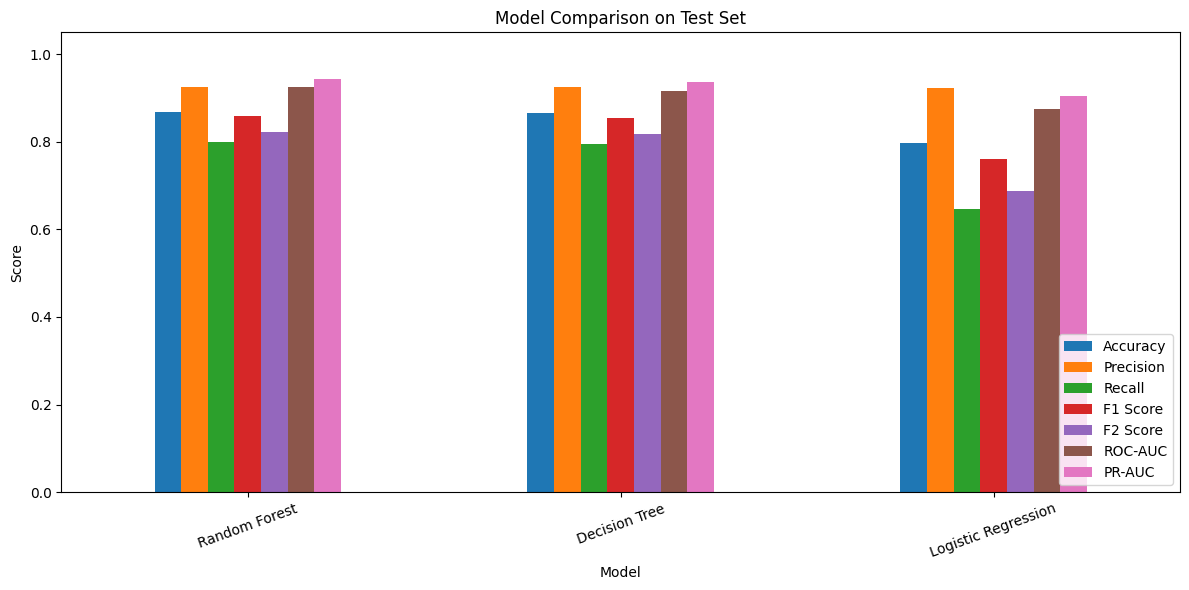

In [22]:
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "F2 Score",
    "ROC-AUC",
    "PR-AUC",
]

comparison_plot_data = results_df.set_index("Model")[metric_columns]

fig, ax = plt.subplots(figsize=(12, 6))
comparison_plot_data.plot(kind="bar", ax=ax)
ax.set_title("Model Comparison on Test Set")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=20)
ax.legend(loc="lower right")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


Precision-recall curves show the relationship between precision and recall across decision thresholds. PR-AUC is especially helpful for phishing detection because it focuses on the positive phishing class and makes the cost of missing positive cases easier to inspect.


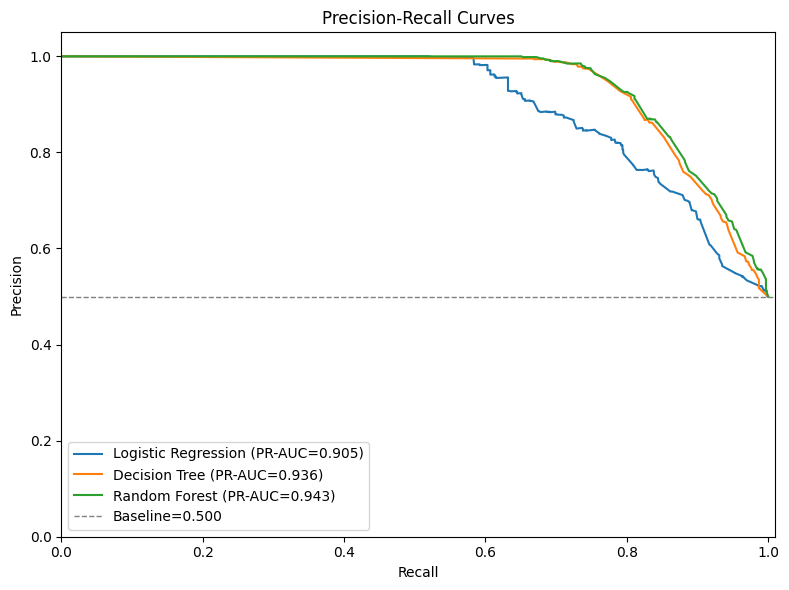

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))

for model_name, y_score in test_scores.items():
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    pr_auc = average_precision_score(y_test, y_score)
    ax.plot(recall, precision, label=f"{model_name} (PR-AUC={pr_auc:.3f})")

baseline = y_test.mean()
ax.axhline(baseline, color="gray", linestyle="--", linewidth=1, label=f"Baseline={baseline:.3f}")
ax.set_title("Precision-Recall Curves")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1.01)
ax.set_ylim(0, 1.05)
ax.legend(loc="lower left")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "precision_recall_curves.png", dpi=150, bbox_inches="tight")
plt.show()


# 7 Duplicate Row Robustness Analysis

To assess robustness, this section evaluates how model performance changes when exact duplicate rows are removed. Repeated observations can make a random train-test split easier if identical records appear in both sets, so this analysis tests whether the baseline results depend on duplicated data.


In [24]:
duplicate_rows_found = int(df.duplicated().sum())
df_deduplicated = df.drop_duplicates().copy()

original_label_counts = df[target_column].value_counts().sort_index()
deduplicated_label_counts = df_deduplicated[target_column].value_counts().sort_index()

duplicate_experiment_summary = pd.DataFrame({
    "Dataset": ["Original", "Deduplicated"],
    "Rows": [len(df), len(df_deduplicated)],
    "Duplicate Rows Found": [duplicate_rows_found, int(df_deduplicated.duplicated().sum())],
    "Legitimate Rows (Label 0)": [
        int(original_label_counts.get(0, 0)),
        int(deduplicated_label_counts.get(0, 0)),
    ],
    "Phishing Rows (Label 1)": [
        int(original_label_counts.get(1, 0)),
        int(deduplicated_label_counts.get(1, 0)),
    ],
    "Phishing Rate": [
        float((df[target_column] == 1).mean()),
        float((df_deduplicated[target_column] == 1).mean()),
    ],
})

display(duplicate_experiment_summary.style.format({
    "Phishing Rate": "{:.3f}",
}))


,Dataset,Rows,Duplicate Rows Found,Legitimate Rows (Label 0),Phishing Rows (Label 1),Phishing Rate
0,Original,10000,5626,5000,5000,0.500
1,Deduplicated,4374,0,529,3845,0.879


In [25]:
def evaluate_random_split_dataset(input_df, dataset_name):
    X_data = input_df.drop(columns=excluded_columns)
    y_data = input_df[target_column]

    X_train_data, X_test_data, y_train_data, y_test_data = train_test_split(
        X_data,
        y_data,
        test_size=0.2,
        random_state=42,
        stratify=y_data,
    )

    result_table, _, _, _ = evaluate_model_suite(
        X_train_data,
        X_test_data,
        y_train_data,
        y_test_data,
    )
    result_table.insert(0, "Dataset", dataset_name)
    result_table.insert(1, "Rows", len(input_df))
    return result_table


duplicate_experiment_results = pd.concat([
    evaluate_random_split_dataset(df, "Original"),
    evaluate_random_split_dataset(df_deduplicated, "Deduplicated"),
], ignore_index=True)

display(duplicate_experiment_results[[
    "Dataset",
    "Rows",
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "F2 Score",
    "ROC-AUC",
    "PR-AUC",
]].style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1 Score": "{:.3f}",
    "F2 Score": "{:.3f}",
    "ROC-AUC": "{:.3f}",
    "PR-AUC": "{:.3f}",
}))


,Dataset,Rows,Model,Accuracy,Precision,Recall,F1 Score,F2 Score,ROC-AUC,PR-AUC
0,Original,10000,Random Forest,0.868,0.926,0.800,0.858,0.822,0.926,0.943
1,Original,10000,Decision Tree,0.865,0.925,0.794,0.855,0.817,0.917,0.936
2,Original,10000,Logistic Regression,0.796,0.923,0.647,0.761,0.688,0.874,0.905
3,Deduplicated,4374,Logistic Regression,0.902,0.901,0.997,0.947,0.977,0.905,0.986
4,Deduplicated,4374,Random Forest,0.887,0.907,0.971,0.938,0.958,0.875,0.980
5,Deduplicated,4374,Decision Tree,0.881,0.906,0.965,0.935,0.953,0.805,0.955


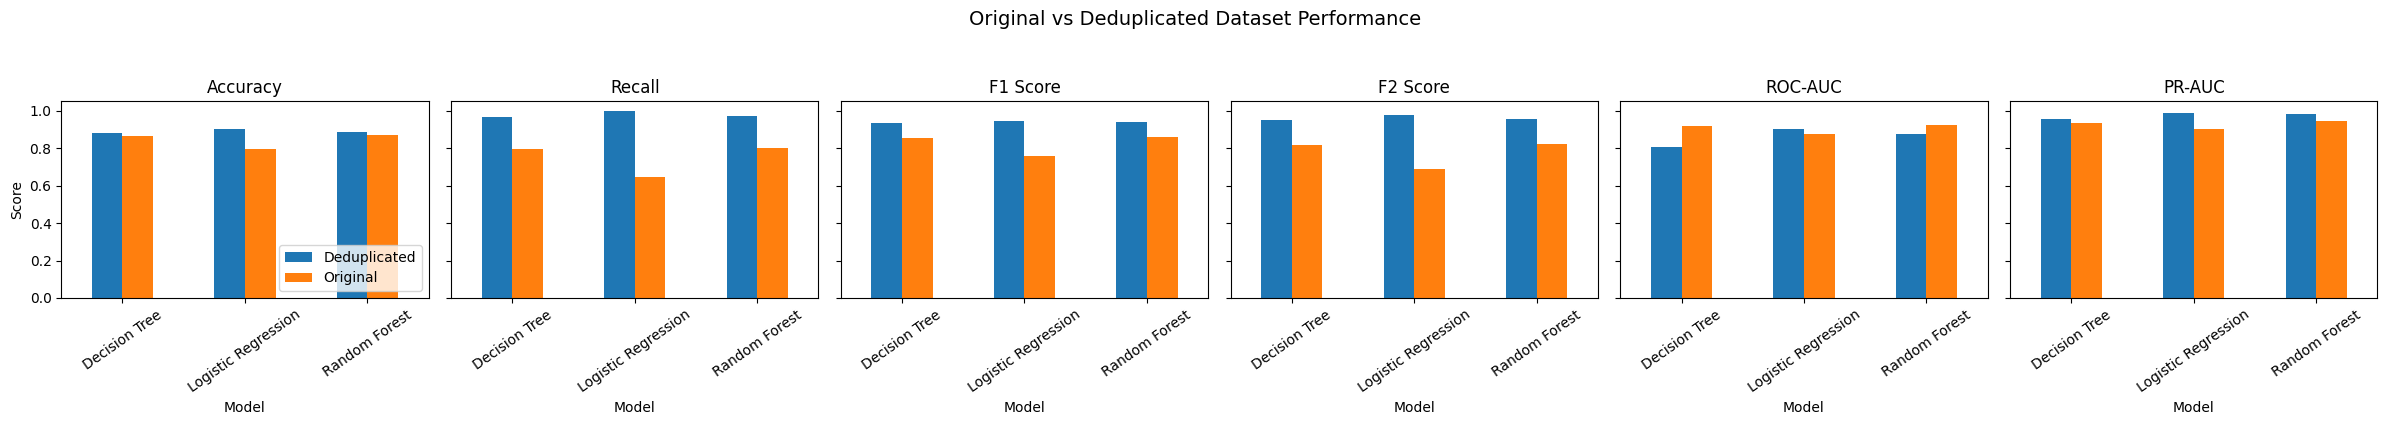

In [26]:
plot_metrics = ["Accuracy", "Recall", "F1 Score", "F2 Score", "ROC-AUC", "PR-AUC"]
fig, axes = plt.subplots(1, len(plot_metrics), figsize=(4 * len(plot_metrics), 4), sharey=True)

for ax, metric in zip(axes, plot_metrics):
    metric_data = duplicate_experiment_results.pivot(index="Model", columns="Dataset", values=metric)
    metric_data.plot(kind="bar", ax=ax)
    ax.set_title(metric)
    ax.set_xlabel("Model")
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=35)
    if ax is not axes[0]:
        ax.get_legend().remove()

axes[0].set_ylabel("Score")
axes[0].legend(loc="lower right")
fig.suptitle("Original vs Deduplicated Dataset Performance", y=1.05, fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "duplicate_experiment_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


This robustness analysis should be interpreted carefully. Removing duplicate rows greatly reduces the dataset size and changes the class balance, so the deduplicated scores are not a simple apples-to-apples comparison with the original balanced dataset. In this run, deduplication exposes that many repeated records were concentrated in one class, which means duplicates can affect both estimated performance and the label distribution. The main conclusion is therefore not simply that deduplication improves or hurts performance, but that duplicate rows are a data-quality risk and can make random-split results less reliable.


# 8 Domain-Aware Generalization Analysis

This section evaluates generalization under a stricter domain-aware split. A random row split can leak domain-specific patterns when the same domain appears in both training and testing rows, so this analysis uses `GroupShuffleSplit` with `Domain` as the grouping column to keep each domain entirely on one side of the split.


In [27]:
from sklearn.model_selection import GroupShuffleSplit

groups = df["Domain"]
group_splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
group_train_idx, group_test_idx = next(group_splitter.split(X, y, groups=groups))

X_train_grouped = X.iloc[group_train_idx]
X_test_grouped = X.iloc[group_test_idx]
y_train_grouped = y.iloc[group_train_idx]
y_test_grouped = y.iloc[group_test_idx]

train_domains = set(df.iloc[group_train_idx]["Domain"])
test_domains = set(df.iloc[group_test_idx]["Domain"])
overlapping_domains = train_domains.intersection(test_domains)

assert len(overlapping_domains) == 0, "Grouped split failed: at least one domain appears in both train and test."

grouped_split_summary = pd.DataFrame({
    "Split": ["Train", "Test"],
    "Rows": [len(X_train_grouped), len(X_test_grouped)],
    "Unique Domains": [len(train_domains), len(test_domains)],
    "Label 0 Rate": [(y_train_grouped == 0).mean(), (y_test_grouped == 0).mean()],
    "Label 1 Rate": [(y_train_grouped == 1).mean(), (y_test_grouped == 1).mean()],
})

grouped_split_summary


,Split,Rows,Unique Domains,Label 0 Rate,Label 1 Rate
0,Train,8205,2842,0.503839,0.496161
1,Test,1795,711,0.482451,0.517549


In [28]:
grouped_results_df, grouped_trained_models, grouped_predictions, grouped_scores = evaluate_model_suite(
    X_train_grouped,
    X_test_grouped,
    y_train_grouped,
    y_test_grouped,
)

grouped_results_for_comparison = grouped_results_df.copy()
grouped_results_for_comparison.insert(0, "Split", "Grouped by Domain")

random_results_for_comparison = results_df.copy()
random_results_for_comparison.insert(0, "Split", "Random Row Split")

grouped_split_comparison = pd.concat([
    random_results_for_comparison,
    grouped_results_for_comparison,
], ignore_index=True)

display(grouped_split_comparison[[
    "Split",
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "F2 Score",
    "ROC-AUC",
    "PR-AUC",
]].style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1 Score": "{:.3f}",
    "F2 Score": "{:.3f}",
    "ROC-AUC": "{:.3f}",
    "PR-AUC": "{:.3f}",
}))


,Split,Model,Accuracy,Precision,Recall,F1 Score,F2 Score,ROC-AUC,PR-AUC
0,Random Row Split,Random Forest,0.868,0.926,0.800,0.858,0.822,0.926,0.943
1,Random Row Split,Decision Tree,0.865,0.925,0.794,0.855,0.817,0.917,0.936
2,Random Row Split,Logistic Regression,0.796,0.923,0.647,0.761,0.688,0.874,0.905
3,Grouped by Domain,Decision Tree,0.771,0.771,0.792,0.782,0.788,0.825,0.839
4,Grouped by Domain,Random Forest,0.769,0.768,0.794,0.781,0.789,0.844,0.887
5,Grouped by Domain,Logistic Regression,0.802,0.924,0.672,0.778,0.711,0.848,0.899


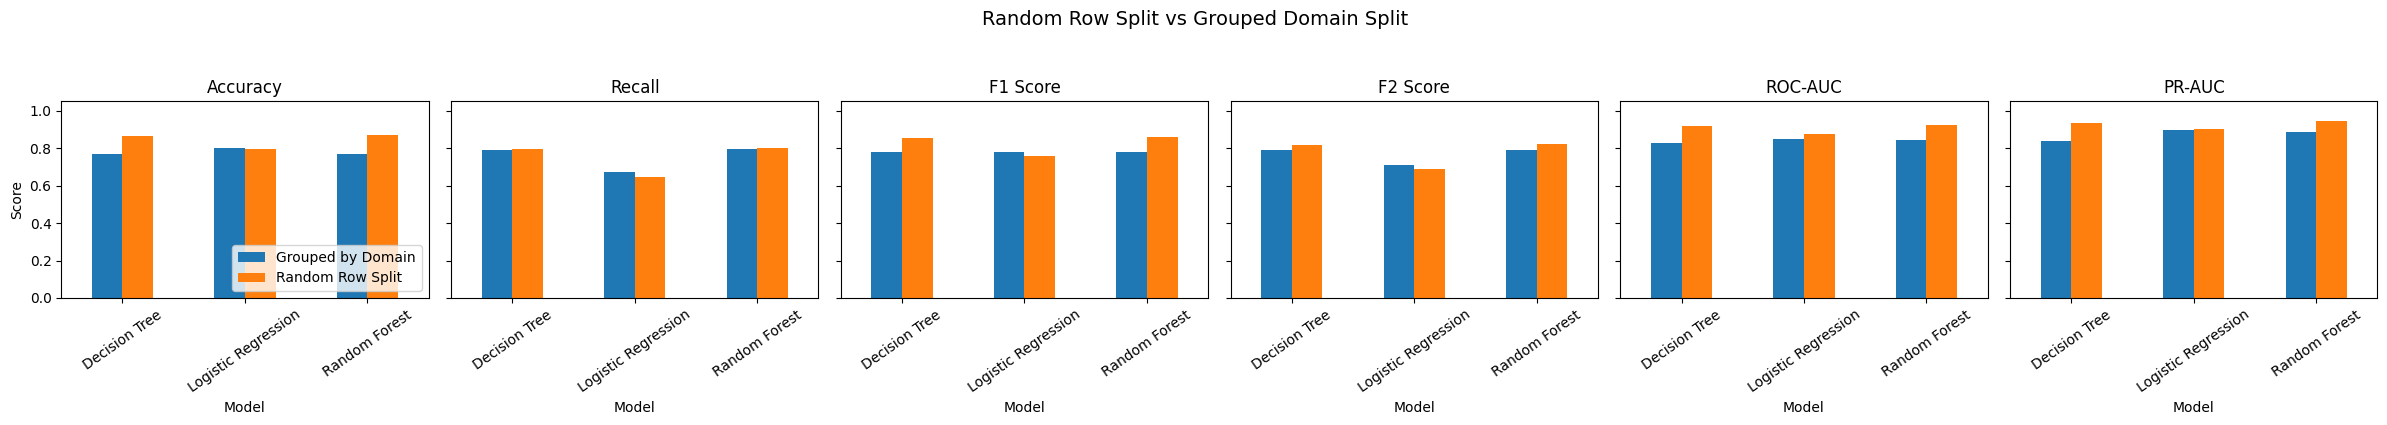

In [29]:
plot_metrics = ["Accuracy", "Recall", "F1 Score", "F2 Score", "ROC-AUC", "PR-AUC"]
fig, axes = plt.subplots(1, len(plot_metrics), figsize=(4 * len(plot_metrics), 4), sharey=True)

for ax, metric in zip(axes, plot_metrics):
    metric_data = grouped_split_comparison.pivot(index="Model", columns="Split", values=metric)
    metric_data.plot(kind="bar", ax=ax)
    ax.set_title(metric)
    ax.set_xlabel("Model")
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=35)
    if ax is not axes[0]:
        ax.get_legend().remove()

axes[0].set_ylabel("Score")
axes[0].legend(loc="lower right")
fig.suptitle("Random Row Split vs Grouped Domain Split", y=1.05, fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "grouped_split_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


A performance drop under the grouped split would suggest that the random split benefited from domain leakage. The grouped split is a stricter estimate of generalization because it evaluates models on domains that were not observed during training.


Confusion matrices show the actual counts of correct and incorrect predictions for each class. They are especially useful in phishing detection because they separate false positives from false negatives instead of combining all errors into a single score.

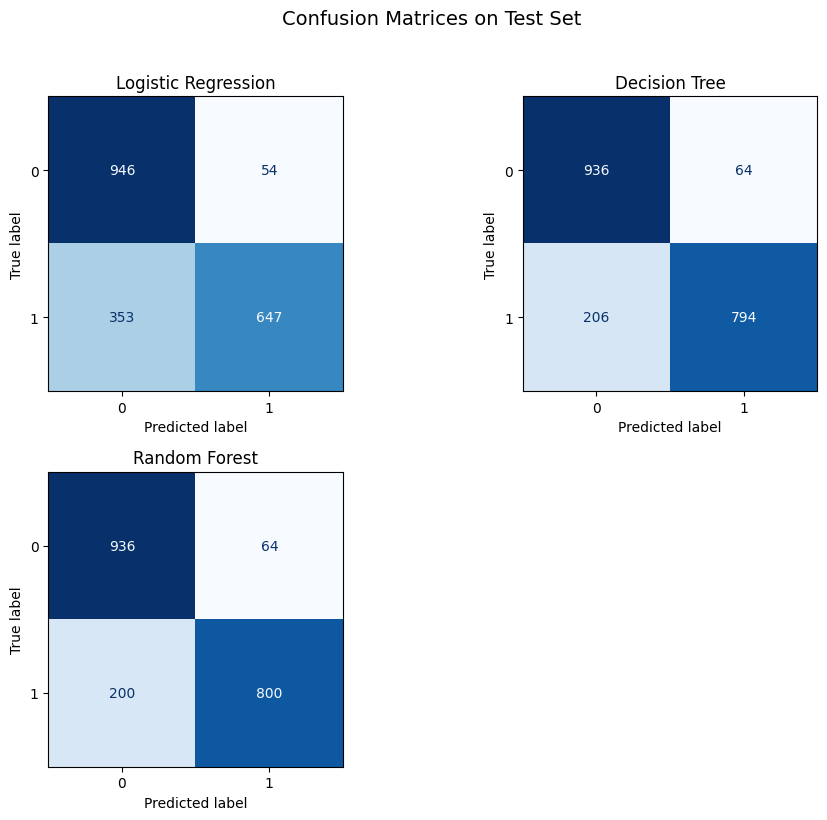

In [30]:
n_models = len(test_predictions)
n_columns = 2
n_rows = math.ceil(n_models / n_columns)

fig, axes = plt.subplots(n_rows, n_columns, figsize=(10, 4 * n_rows))
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for ax, (model_name, y_pred) in zip(axes, test_predictions.items()):
    matrix = confusion_matrix(y_test, y_pred)
    cm_display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=[0, 1])
    cm_display.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(model_name)

for ax in axes[n_models:]:
    ax.set_visible(False)

fig.suptitle("Confusion Matrices on Test Set", y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

### Feature Importance

The best-performing model is inspected to identify which engineered features contribute most to its predictions. For tree-based models, this uses feature importance values. For Logistic Regression, it uses the largest absolute standardized coefficients.

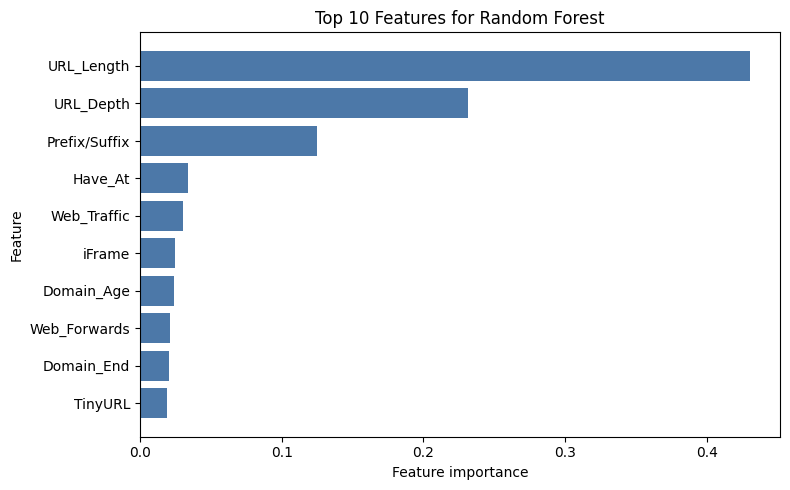

,Feature,Importance
2,URL_Length,0.430050
3,URL_Depth,0.231328
7,Prefix/Suffix,0.124768
1,Have_At,0.033860
9,Web_Traffic,0.030200
12,iFrame,0.024995
10,Domain_Age,0.024135
15,Web_Forwards,0.021045
11,Domain_End,0.020543
6,TinyURL,0.018992


In [31]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

if hasattr(best_model, "feature_importances_"):
    importance_values = best_model.feature_importances_
    importance_label = "Feature importance"
elif best_model_name == "Logistic Regression":
    importance_values = abs(best_model.named_steps["classifier"].coef_[0])
    importance_label = "Absolute standardized coefficient"
else:
    importance_values = None
    importance_label = None

if importance_values is not None:
    importance_df = pd.DataFrame({
        "Feature": numeric_columns,
        "Importance": importance_values,
    }).sort_values("Importance", ascending=False).head(10)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(importance_df["Feature"][::-1], importance_df["Importance"][::-1], color="#4C78A8")
    ax.set_title(f"Top 10 Features for {best_model_name}")
    ax.set_xlabel(importance_label)
    ax.set_ylabel("Feature")

    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()

    display(importance_df)
else:
    display(Markdown(
        f"Feature importance is not available for **{best_model_name}** with the current model object."
    ))

The highest-ranked features above are the strongest contributors for the selected model. They indicate which handcrafted URL, domain, or page-behavior signals are most useful for separating phishing websites from legitimate websites in this dataset.

# 9 Error Analysis

This section inspects mistakes made by the best-performing model according to F1 Score. Error analysis is useful because aggregate metrics can hide the practical consequences of different error types.

In [32]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
best_predictions = test_predictions[best_model_name]

error_analysis_df = X_test.copy()
error_analysis_df.insert(0, "Domain", df.loc[X_test.index, "Domain"])
error_analysis_df["actual_label"] = y_test
error_analysis_df["predicted_label"] = best_predictions
error_analysis_df["error_type"] = "correct"
error_analysis_df.loc[
    (error_analysis_df["actual_label"] == 0) & (error_analysis_df["predicted_label"] == 1),
    "error_type",
] = "false_positive"
error_analysis_df.loc[
    (error_analysis_df["actual_label"] == 1) & (error_analysis_df["predicted_label"] == 0),
    "error_type",
] = "false_negative"

error_counts = error_analysis_df["error_type"].value_counts()

print(f"Best model by F1 Score: {best_model_name}")
error_counts

Best model by F1 Score: Random Forest


error_type
correct           1736
false_negative     200
false_positive      64
Name: count, dtype: int64

False positives are legitimate websites classified as phishing. False negatives are phishing websites classified as legitimate. In this domain, false negatives are particularly dangerous because they allow malicious websites to pass through the detector and reach users, increasing the risk of credential theft, financial fraud, or malware exposure.

In [33]:
false_positives = error_analysis_df[error_analysis_df["error_type"] == "false_positive"]
false_negatives = error_analysis_df[error_analysis_df["error_type"] == "false_negative"]
misclassified_samples = error_analysis_df[error_analysis_df["error_type"] != "correct"]
error_display_columns = [
    "Domain",
    "actual_label",
    "predicted_label",
    "error_type",
] + X_test.columns.tolist()

print(f"False positives: {len(false_positives)}")
print(f"False negatives: {len(false_negatives)}")

misclassified_samples[error_display_columns].head(10)

False positives: 64
False negatives: 200


,Domain,actual_label,predicted_label,error_type,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards
8102,sunoffer.club,1,0,false_negative,0,0,1,4,0,0,0,0,0,1,0,1,0,0,1,0
7181,sunoffer.club,1,0,false_negative,0,0,1,4,0,0,0,0,0,1,0,1,0,0,1,0
8478,officialtobinbell.com,1,0,false_negative,0,0,1,1,0,0,0,0,0,1,0,1,0,0,1,0
6048,yrcpi5xiyk5p6jjyzy3zhybgy6vsiymp4wrfptss3xqpca...,1,0,false_negative,0,0,1,1,1,0,0,0,0,0,1,1,0,0,1,0
6751,di448620c5wng.cloudfront.net,1,0,false_negative,0,0,1,3,0,0,0,0,1,1,1,1,0,0,1,0
5264,communityreview.info,1,0,false_negative,0,0,1,2,0,0,0,0,0,1,0,0,0,0,1,0
8797,beyondstateofmind.com,1,0,false_negative,0,0,1,4,0,0,0,0,0,0,0,1,0,0,1,0
5889,support.paypal.com.kulturabgru.kultura4.cp.reg...,1,0,false_negative,0,0,1,1,0,0,0,0,0,0,0,1,0,0,1,0
9728,blog.cellprofiler.org,1,0,false_negative,0,0,1,1,0,0,0,0,0,0,0,1,0,0,1,0
5075,livraisonspeed01.cloudaccess.host,1,0,false_negative,0,0,1,2,0,0,0,0,0,1,1,1,0,0,1,0


Possible reasons for observed errors include overlapping feature patterns between legitimate and phishing sites, coarse binary feature encoding, noisy or outdated domain-related signals, and limited representation of newer phishing tactics. Because the raw `Domain` text is not used directly, the model may also miss lexical patterns that were not captured by the handcrafted feature extraction process.

# 10 Threshold and Risk Trade-off Analysis

To study deployment trade-offs, this section evaluates several classification thresholds for the Random Forest model when available. The default threshold is 0.5, but phishing detection has asymmetric risk, so lowering the threshold may reduce false negatives while increasing false positives.


In [34]:
threshold_model_name = "Random Forest" if "Random Forest" in trained_models else best_model_name
threshold_model = trained_models[threshold_model_name]
threshold_scores = get_positive_class_scores(threshold_model, X_test)
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

threshold_rows = []
for threshold in thresholds:
    threshold_predictions = (threshold_scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, threshold_predictions, labels=[0, 1]).ravel()
    threshold_rows.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, threshold_predictions, zero_division=0),
        "Recall": recall_score(y_test, threshold_predictions, zero_division=0),
        "F1 Score": f1_score(y_test, threshold_predictions, zero_division=0),
        "F2 Score": fbeta_score(y_test, threshold_predictions, beta=2, zero_division=0),
        "False Positives": fp,
        "False Negatives": fn,
    })

threshold_analysis_df = pd.DataFrame(threshold_rows)
print(f"Threshold analysis model: {threshold_model_name}")
display(threshold_analysis_df.style.format({
    "Threshold": "{:.1f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1 Score": "{:.3f}",
    "F2 Score": "{:.3f}",
}))


Threshold analysis model: Random Forest


,Threshold,Precision,Recall,F1 Score,F2 Score,False Positives,False Negatives
0,0.2,0.704,0.928,0.801,0.873,390,72
1,0.3,0.863,0.843,0.853,0.847,134,157
2,0.4,0.904,0.815,0.857,0.831,87,185
3,0.5,0.926,0.800,0.858,0.822,64,200
4,0.6,0.978,0.741,0.843,0.779,17,259
5,0.7,0.985,0.730,0.839,0.770,11,270


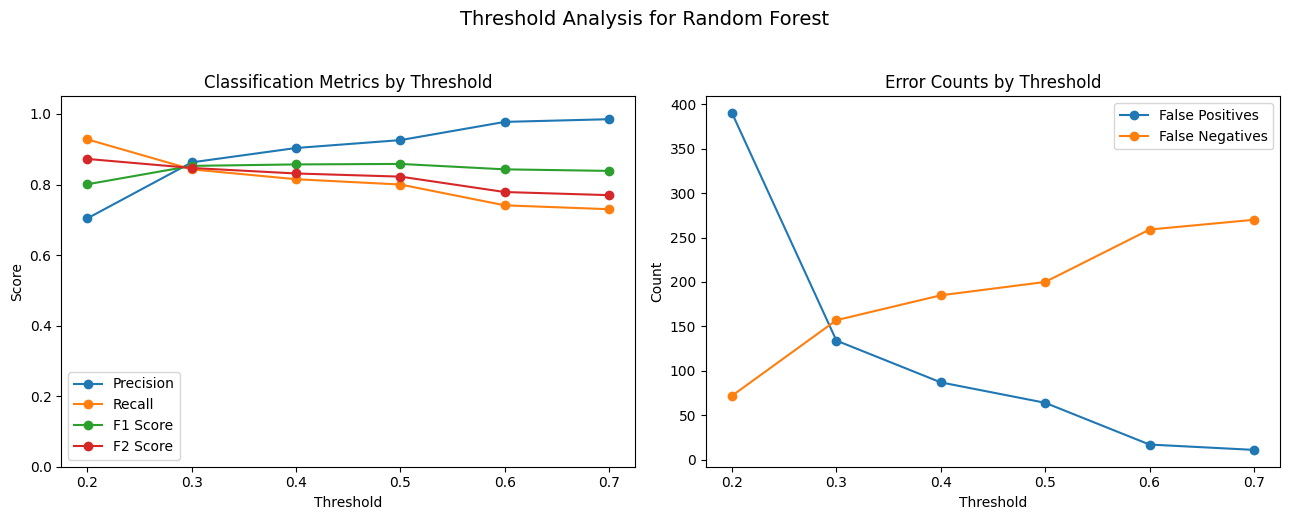

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for metric in ["Precision", "Recall", "F1 Score", "F2 Score"]:
    axes[0].plot(threshold_analysis_df["Threshold"], threshold_analysis_df[metric], marker="o", label=metric)
axes[0].set_title("Classification Metrics by Threshold")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc="lower left")

axes[1].plot(threshold_analysis_df["Threshold"], threshold_analysis_df["False Positives"], marker="o", label="False Positives")
axes[1].plot(threshold_analysis_df["Threshold"], threshold_analysis_df["False Negatives"], marker="o", label="False Negatives")
axes[1].set_title("Error Counts by Threshold")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Count")
axes[1].legend(loc="best")

fig.suptitle(f"Threshold Analysis for {threshold_model_name}", y=1.03, fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "threshold_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


Lowering the threshold usually increases recall because more websites are classified as phishing, which can reduce false negatives. The trade-off is that more legitimate websites may be flagged, increasing false positives. This matters in phishing detection because false negatives expose users to active threats, while false positives create friction, support burden, and possible loss of trust. A deployment threshold should therefore be chosen based on the acceptable balance between user protection and operational cost.


# 11 Comparison with the Original Project

The original repository describes a supervised phishing website detection workflow using 10,000 URLs: 5,000 phishing URLs and 5,000 legitimate URLs. It extracts 17 handcrafted features from URL, domain, HTML, and JavaScript properties, splits the data into an 80/20 train/test split, trains several machine learning and neural network models, and reports the best model based mainly on accuracy.

The original project lists Decision Tree, Random Forest, Multilayer Perceptron, Autoencoder Neural Network, Support Vector Machine, and a boosting-style classifier. This reproduction trains Logistic Regression, Decision Tree, and Random Forest only. The evaluation uses a broader metric set: Accuracy, Precision, Recall, F1 Score, F2 Score, Matthews Correlation Coefficient, ROC-AUC, and PR-AUC, while the original README primarily emphasizes training and testing accuracy.


In [36]:
original_reported_results = pd.DataFrame({
    "Source": ["Original README"],
    "Reported Best Model": ["Boosting-style classifier"],
    "Reported Training Accuracy": [0.867],
    "Reported Testing Accuracy": [0.858],
})

our_best_result = results_df.head(1).copy()
our_best_result.insert(0, "Source", "This reproduction")

display(original_reported_results)
display(our_best_result)

,Source,Reported Best Model,Reported Training Accuracy,Reported Testing Accuracy
0,Original README,Boosting-style classifier,0.867,0.858


,Source,Model,Accuracy,Precision,Recall,F1 Score,F2 Score,Matthews Correlation Coefficient,ROC-AUC,PR-AUC
2,This reproduction,Random Forest,0.868,0.925926,0.8,0.858369,0.822368,0.742902,0.925654,0.942736


Similarities are expected because both workflows use the same engineered dataset, an 80/20 split, and overlapping tree-based models. Differences may occur because this notebook uses an explicit stratified split with `random_state=42`, includes Logistic Regression as a baseline, evaluates additional metrics, and may use different library versions or model hyperparameters from the original project.

# 12 Critical Evaluation

A strength of the original project is that it uses a clear supervised learning workflow with interpretable handcrafted features and compares multiple model families. The dataset is balanced, the features are saved in a reusable CSV file, and the task is framed around a realistic cybersecurity problem.

The main weaknesses are that the README focuses heavily on accuracy, provides limited detail about validation design and hyperparameter tuning, and does not deeply analyze false positives, false negatives, or data leakage risks. Some claims, such as a large real-world reduction in phishing attacks, are not fully supported by the reported offline experiment.

The dataset is limited because it is a fixed snapshot of URLs and may not represent current phishing campaigns, new evasion strategies, or deployment conditions. Handcrafted features are useful and interpretable, but they can become brittle when attackers adapt their URLs, hosting patterns, or page behavior. Accuracy alone is insufficient because phishing detection has asymmetric risks: missing a phishing site can be much more harmful than incorrectly warning about a legitimate site. Therefore, recall, precision, F1 Score, MCC, ROC-AUC, and confusion matrices are needed for a more responsible evaluation.

Overall, the original conclusion that its boosting-style classifier performs best may be reasonable for the reported experiment, but the broader conclusions about real-world impact are not fully supported without stronger validation, updated data, deployment testing, and analysis of operational error costs.


### Cross-Validation Considerations

This reproduction, like the original project, evaluates model performance using a single train-test split. While this provides a straightforward comparison, future work should employ k-fold cross-validation to obtain more robust estimates of model performance. Cross-validation reduces the dependence on one particular data split and provides a more reliable estimate of how well the models generalize to unseen phishing websites.

# 13 Conclusion

This notebook reproduced the core phishing website detection workflow using the original engineered dataset and evaluated several baseline models. The summary below is generated from `results_df`, so it reflects the models that were actually trained in the current environment.

The final results table reports the held-out test performance for each trained model, sorted by F1 Score from highest to lowest and including recall-weighted and precision-recall metrics.


In [37]:
final_results_table = results_df.rename(
    columns={"Matthews Correlation Coefficient": "MCC"}
)[["Model", "Accuracy", "Precision", "Recall", "F1 Score", "F2 Score", "MCC", "ROC-AUC", "PR-AUC"]]

display(final_results_table.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1 Score": "{:.3f}",
    "F2 Score": "{:.3f}",
    "MCC": "{:.3f}",
    "ROC-AUC": "{:.3f}",
    "PR-AUC": "{:.3f}",
}))


,Model,Accuracy,Precision,Recall,F1 Score,F2 Score,MCC,ROC-AUC,PR-AUC
2,Random Forest,0.868,0.926,0.800,0.858,0.822,0.743,0.926,0.943
1,Decision Tree,0.865,0.925,0.794,0.855,0.817,0.737,0.917,0.936
0,Logistic Regression,0.796,0.923,0.647,0.761,0.688,0.621,0.874,0.905


This comparison highlights whether the leading model performs consistently across precision, recall, F1 Score, F2 Score, MCC, ROC-AUC, and PR-AUC, rather than relying on accuracy alone.


In [38]:
best_result = results_df.iloc[0]

display(Markdown(
    f"The best model in this reproduction is **{best_result['Model']}** "
    f"with F1 Score **{best_result['F1 Score']:.3f}**, "
    f"F2 Score **{best_result['F2 Score']:.3f}**, "
    f"Accuracy **{best_result['Accuracy']:.3f}**, "
    f"Precision **{best_result['Precision']:.3f}**, "
    f"Recall **{best_result['Recall']:.3f}**, "
    f"MCC **{best_result['Matthews Correlation Coefficient']:.3f}**, "
    f"ROC-AUC **{best_result['ROC-AUC']:.3f}**, "
    f"and PR-AUC **{best_result['PR-AUC']:.3f}**."
))


The best model in this reproduction is **Random Forest** with F1 Score **0.858**, F2 Score **0.822**, Accuracy **0.868**, Precision **0.926**, Recall **0.800**, MCC **0.743**, ROC-AUC **0.926**, and PR-AUC **0.943**.

### Dataset Considerations

The dataset used in this study is approximately balanced between phishing and legitimate websites. Because of this, accuracy is a meaningful evaluation metric. However, in cybersecurity applications it is still important to consider precision, recall, F1 Score, F2 Score, Matthews Correlation Coefficient (MCC), ROC-AUC, and PR-AUC, since different types of classification errors have different practical consequences. In particular, failing to detect a phishing website (a false negative) can be significantly more harmful than incorrectly flagging a legitimate website (a false positive).


Key findings are that the dataset is structured and convenient for supervised learning, the `Domain` column should not be used directly as a numeric feature, duplicate-row handling can change both estimated performance and class balance, and grouped domain splits provide a stricter leakage-aware evaluation. Future improvements should include cross-validation, hyperparameter tuning, calibration checks, newer datasets, lexical domain feature engineering, and evaluation under realistic deployment scenarios.


## Key Takeaways

- Random Forest achieved the strongest overall performance on the regular random split for this dataset.
- F2 Score, PR-AUC, precision-recall curves, and threshold analysis provide a more security-relevant view than accuracy alone.
- Duplicate rows are a major data-quality issue; removing them changes the dataset size and class balance, so deduplicated results require careful interpretation.
- The grouped split by `Domain` shows that performance drops when domain leakage is reduced, making it a stricter test of generalization to unseen domains.
- Lower classification thresholds can reduce false negatives, but they may increase false positives and operational review burden.
